# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (_Kaggle_, _UCI ML Repository_, _Open Data_) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**


Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.


In [15]:
# Import Library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

# **3. Memuat Dataset**


Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan


In [16]:
# Load dataset
data = pd.read_csv("../loan_default.csv")

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


### **A. Overview Data**


In [17]:
# Cek baris dan kolom dari dataframe
data.shape

(255347, 18)

In [18]:
# Melihat sampling 5 baris teratas
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [19]:
#  Menampilkan informasi ringkas dari data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [20]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
data.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [21]:
# Menampilkan isi kolom Default dengan unik
data["Default"].unique()

array([0, 1])

In [22]:
# Cek keseimbangan nilai Default
data["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [23]:
# Cek prosentase nilai Default
data["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

### **B. Visualisasi Data Awal**


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'LoanAmount'}>],
       [<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'MonthsEmployed'}>,
        <Axes: title={'center': 'NumCreditLines'}>],
       [<Axes: title={'center': 'InterestRate'}>,
        <Axes: title={'center': 'LoanTerm'}>,
        <Axes: title={'center': 'DTIRatio'}>],
       [<Axes: title={'center': 'Default'}>, <Axes: >, <Axes: >]],
      dtype=object)

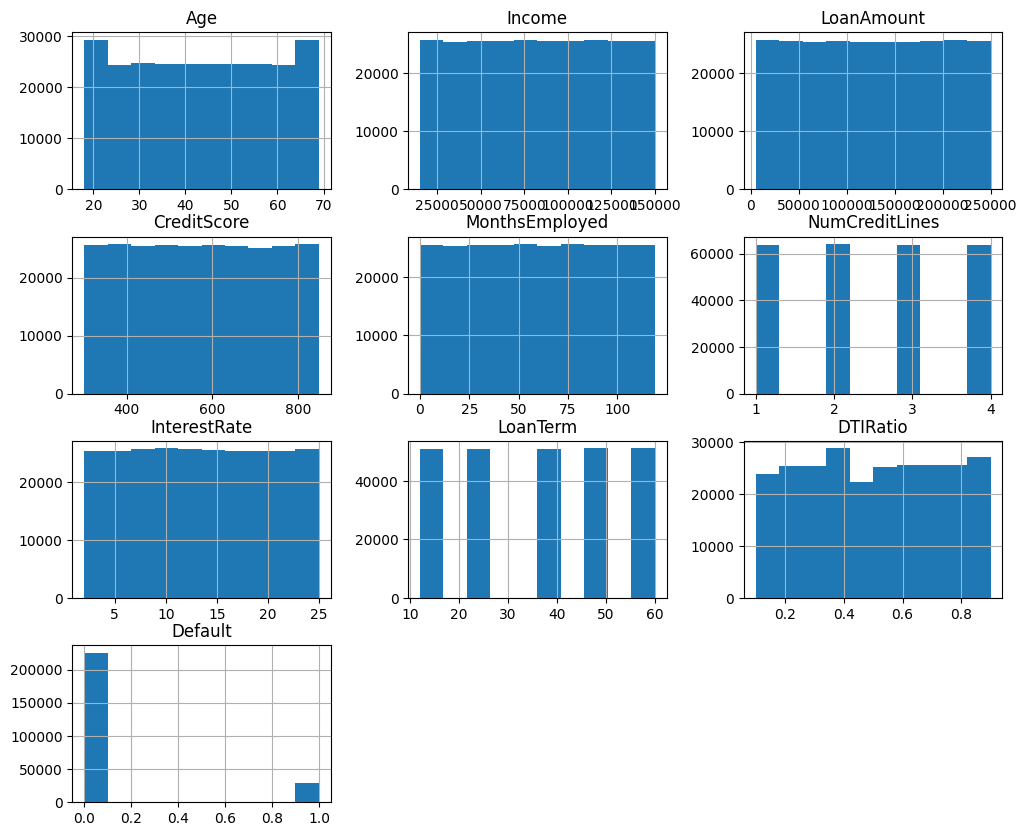

In [24]:
# Diagaram garis
data.hist(figsize=(12, 10))

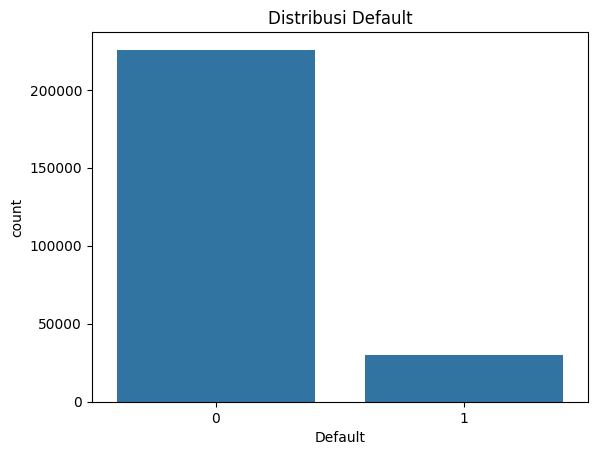

In [25]:
# Visualisasi kolom Default
sns.countplot(x="Default", data=data)
plt.title("Distribusi Default")
plt.show()

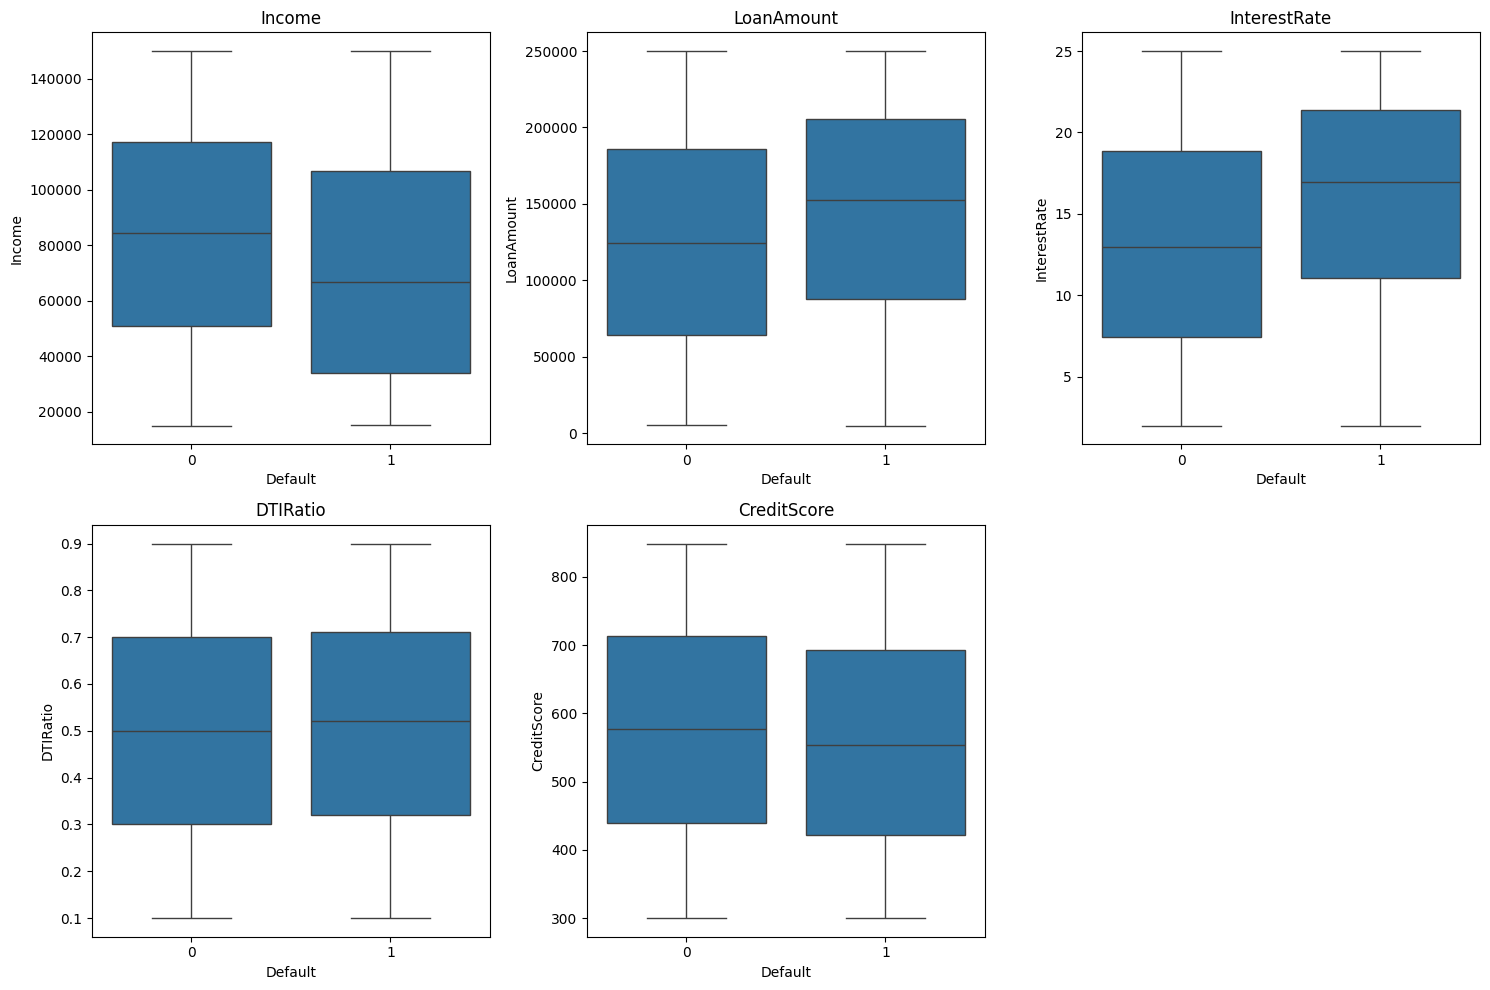

In [26]:
# Boxplot fitur numerik penting
cols = [
    "Income",
    "LoanAmount",
    "InterestRate",
    "DTIRatio",
    "CreditScore",
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="Default", y=col, data=data)
    plt.title(col)

plt.tight_layout()
plt.show()

In [27]:
# Cek korelasi fitur vs target
data.corr(numeric_only=True)["Default"].sort_values(ascending=False)

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

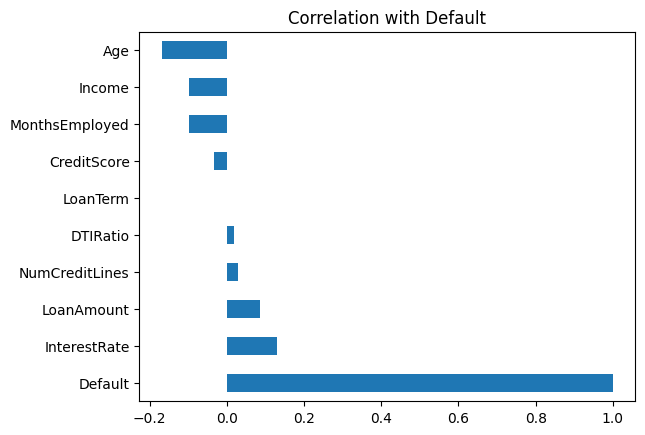

In [28]:
# Visualisasikan
corr_target = data.corr(numeric_only=True)["Default"].sort_values(ascending=False)

corr_target.plot(kind="barh")
plt.title("Correlation with Default")
plt.show()

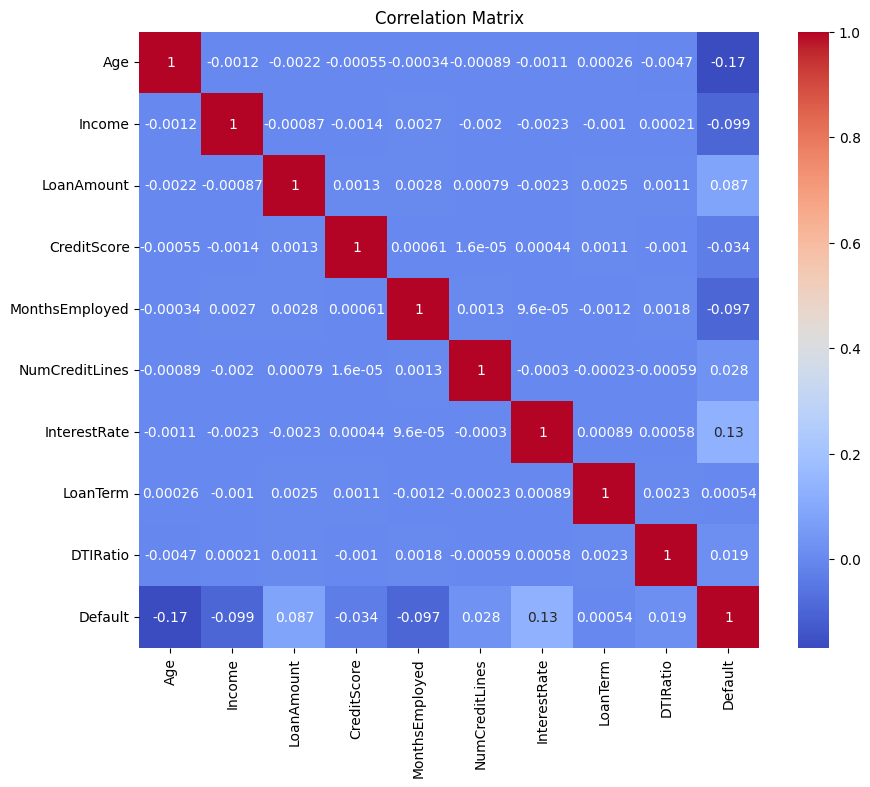

In [29]:
# Visualisasi korelasi antar fitur
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [30]:
# Cek korelasi crosstab data kategorikal dengan target
categorical_columns = data.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(pd.crosstab(data[col], data["Default"], normalize="index"))


=== LoanID ===
Default       0    1
LoanID              
0003HW9UAA  1.0  0.0
000ELHLBPV  0.0  1.0
000G6CHJON  1.0  0.0
000K09D0JB  1.0  0.0
000NTH4YTU  1.0  0.0
...         ...  ...
ZZZHT6VWO4  0.0  1.0
ZZZI5YOV9G  0.0  1.0
ZZZMFPZFKE  1.0  0.0
ZZZV1HB132  1.0  0.0
ZZZX015LV2  1.0  0.0

[255347 rows x 2 columns]

=== Education ===
Default             0         1
Education                      
Bachelor's   0.878989  0.121011
High School  0.871211  0.128789
Master's     0.891283  0.108717
PhD          0.894140  0.105860

=== EmploymentType ===
Default                0         1
EmploymentType                    
Full-time       0.905366  0.094634
Part-time       0.880348  0.119652
Self-employed   0.885380  0.114620
Unemployed      0.864471  0.135529

=== MaritalStatus ===
Default               0         1
MaritalStatus                    
Divorced       0.874672  0.125328
Married        0.896028  0.103972
Single         0.880876  0.119124

=== HasMortgage ===
Default             0    

# **5. Data Preprocessing**


Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:

1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.


### **A. Menghapus atau menangani Data Kosong(Missing Values)**


In [31]:
# Melakukan drop pada kolom customerID karena tidak mempengaruhi hasil analisa

data.drop("LoanID", axis=1, inplace=True)

In [32]:
# Cek kembali data Null
data.isnull().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### **B. Menghapus Data Duplikat**


In [33]:
# Cek dataset duplikat

data.duplicated().sum()

0

### **C. Mengatasi Pencilan**


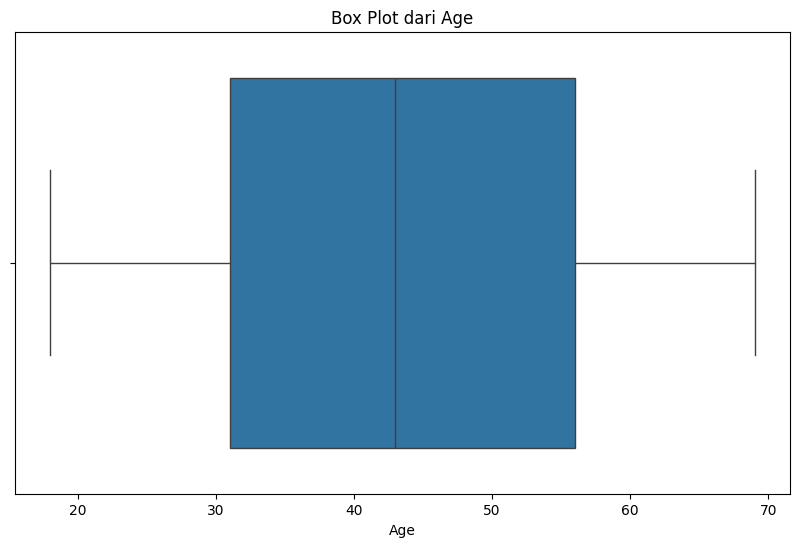

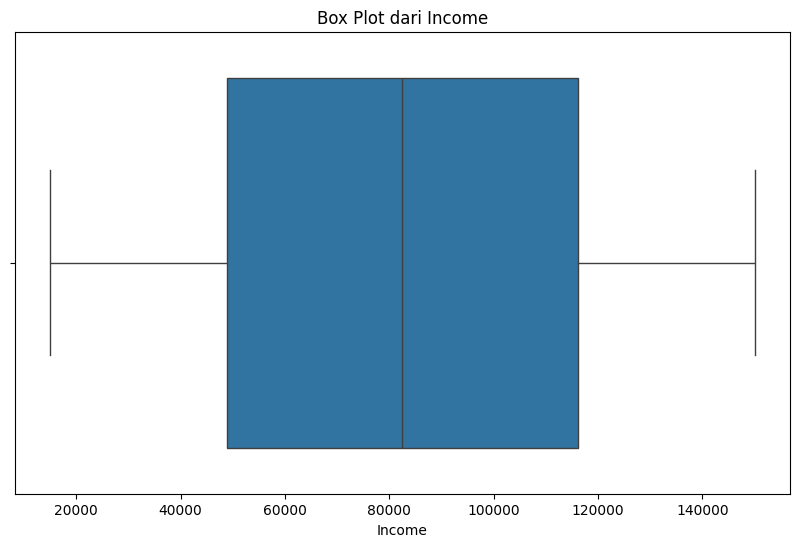

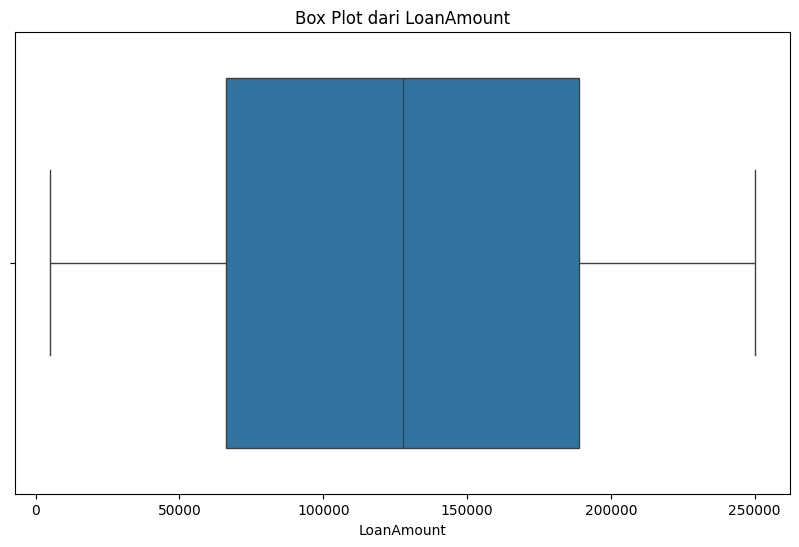

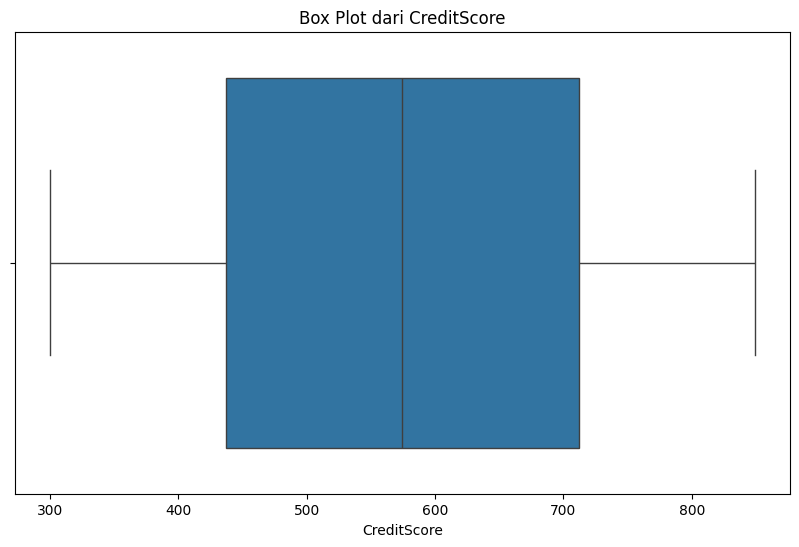

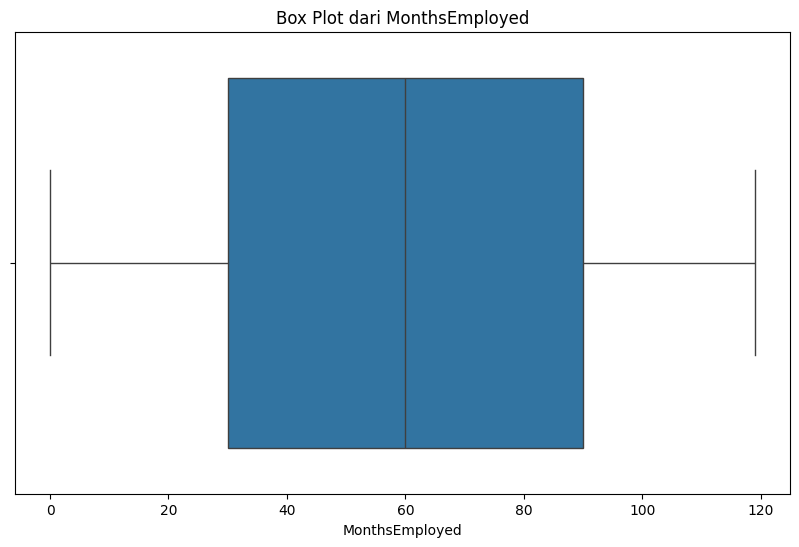

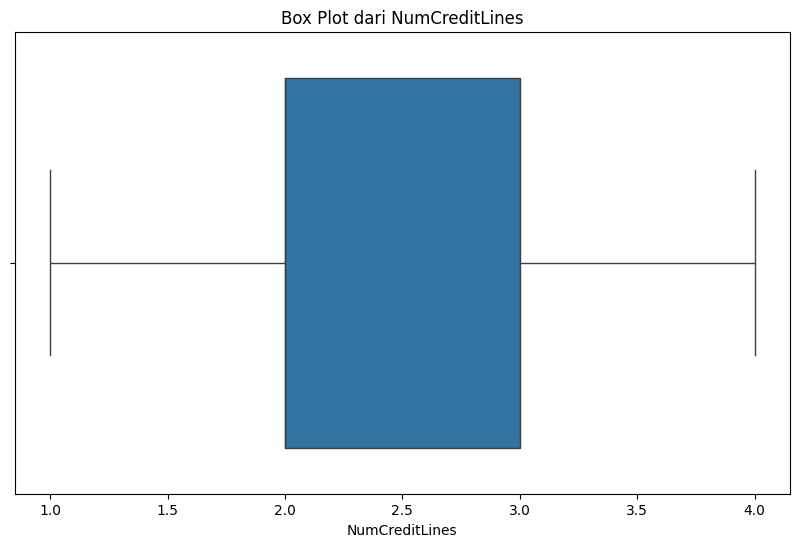

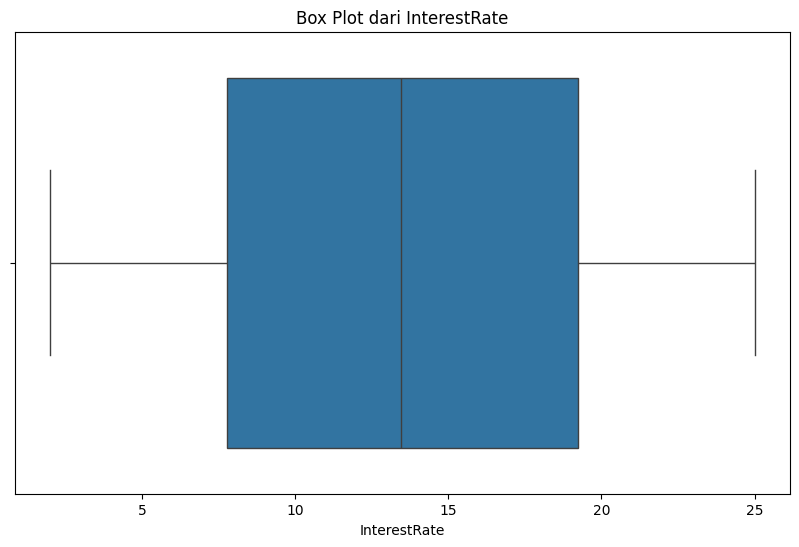

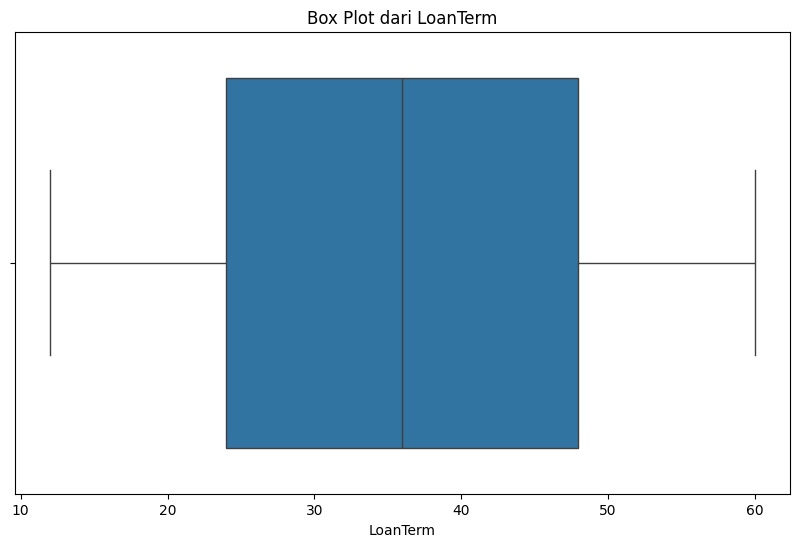

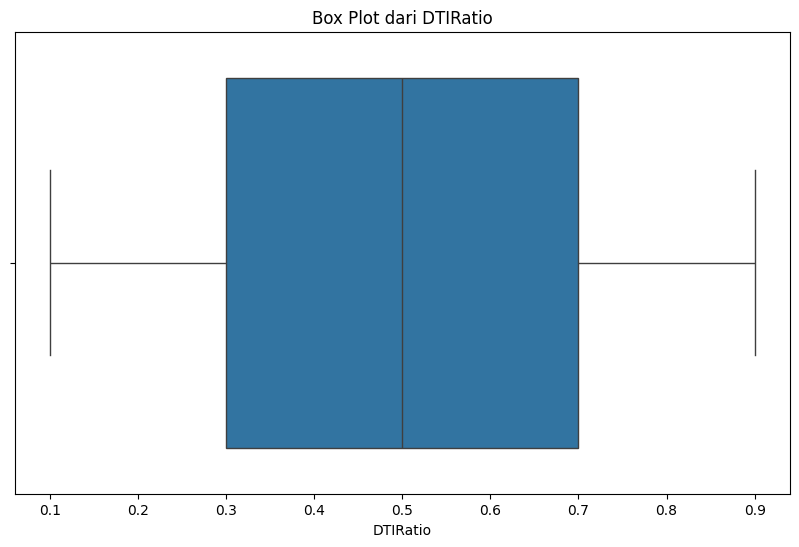

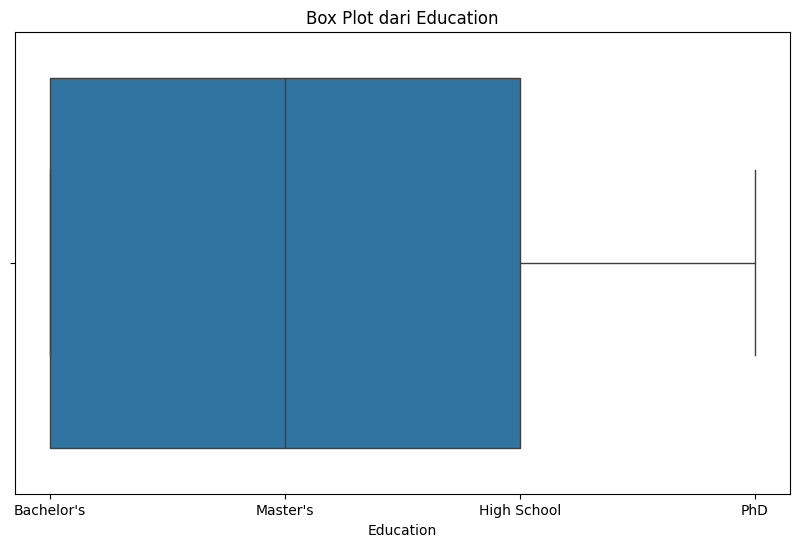

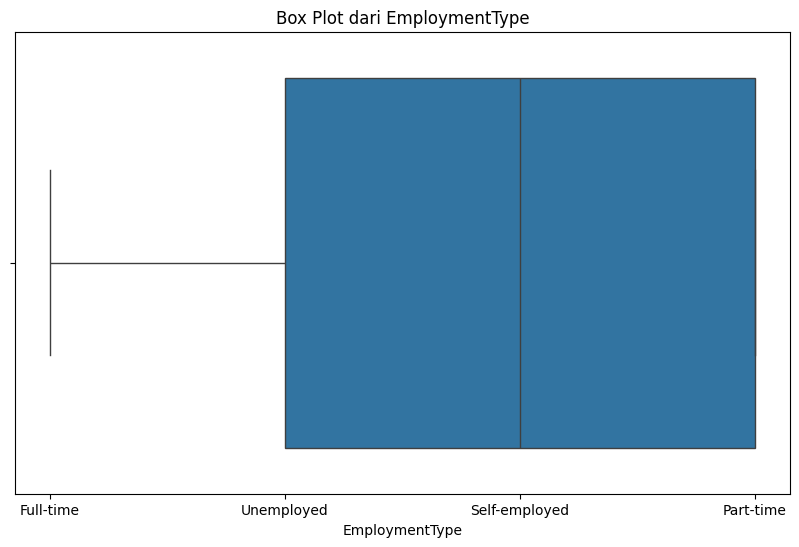

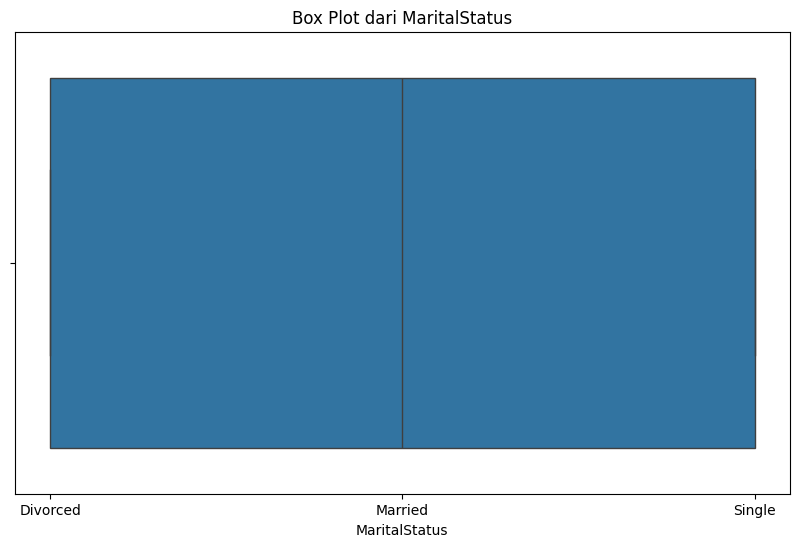

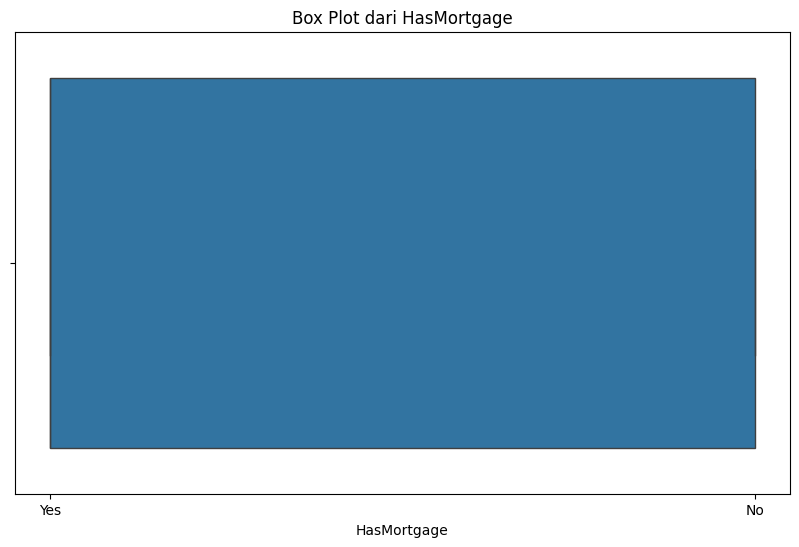

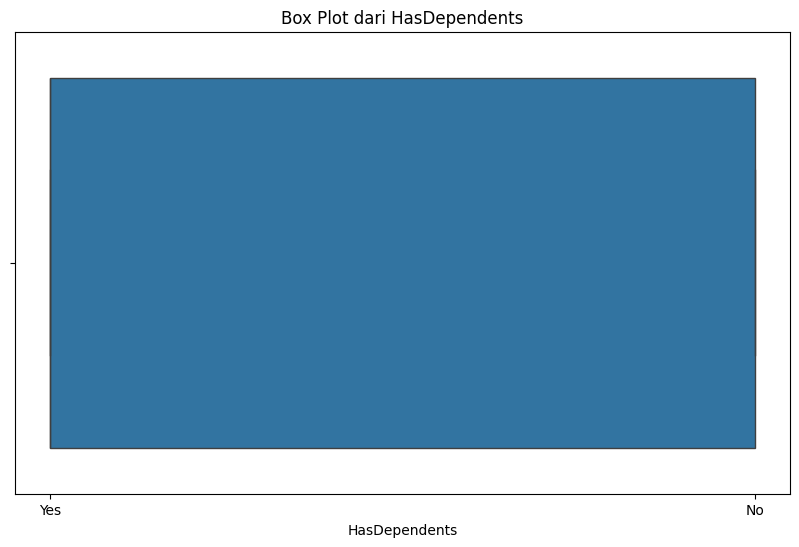

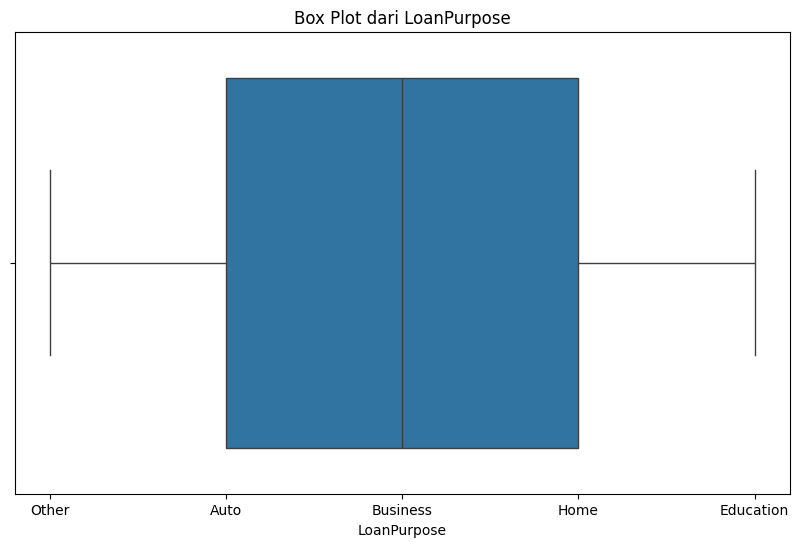

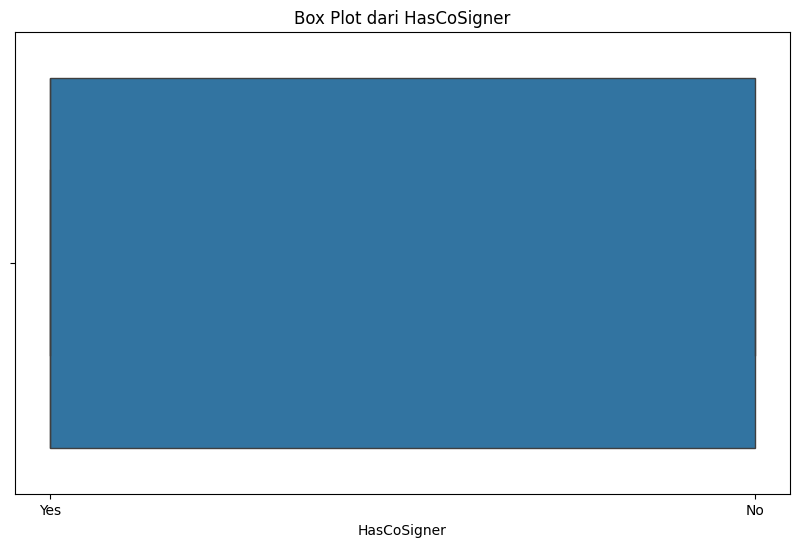

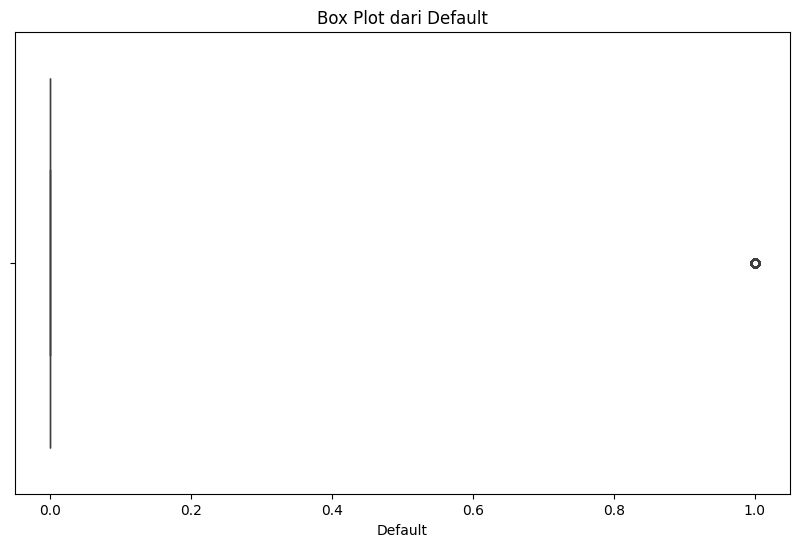

In [34]:
# Cek outliers bisa dilihat dari data diluar boxplot

for fitur in data:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[fitur])
    plt.title(f"Box Plot dari {fitur}")
    plt.show()

### **D. Split Dataset**


In [35]:
data_train, data_test = train_test_split(
    data, test_size=0.05, random_state=42, shuffle=True
)
data_train.reset_index(drop=True, inplace=True)
data_test.reset_index(drop=True, inplace=True)

print(data_train.shape)
print(data_test.shape)

(242579, 17)
(12768, 17)


### **E. Membuat Fungsi Scalling dan Encoding**


In [36]:
os.makedirs("model", exist_ok=True)


def scaling(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1, 1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))

            X_test = np.asanyarray(df_test[feature])
            X_test = X_test.reshape(-1, 1)
            df_test["{}".format(feature)] = scaler.transform(X_test)
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1, 1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))
        return df


def encoding(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            encoder.fit(df[[feature]])

            # Transform df
            transformed = encoder.transform(df[[feature]])
            cols = [f"{feature}_{cat}" for cat in encoder.categories_[0]]
            df_encoded = pd.DataFrame(transformed, columns=cols, index=df.index)
            df = df.drop(columns=[feature]).join(df_encoded)

            # Transform df_test
            transformed_test = encoder.transform(df_test[[feature]])
            df_test_encoded = pd.DataFrame(
                transformed_test, columns=cols, index=df_test.index
            )
            df_test = df_test.drop(columns=[feature]).join(df_test_encoded)

            joblib.dump(encoder, f"model/encoder_{feature}.joblib")

        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            encoder.fit(df[[feature]])

            transformed = encoder.transform(df[[feature]])
            cols = [f"{feature}_{cat}" for cat in encoder.categories_[0]]
            df_encoded = pd.DataFrame(transformed, columns=cols, index=df.index)
            df = df.drop(columns=[feature]).join(df_encoded)

            joblib.dump(encoder, f"model/encoder_{feature}.joblib")

        return df

### **F. Normalisasi dan Standardisasi Fitur**


In [37]:
numerical_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
]

In [38]:
new_data_train, new_data_test = scaling(numerical_columns, data_train, data_test)

### **G. Encoding Data Kategorikal**


In [39]:
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner",
]

In [40]:
new_data_train, new_data_test = encoding(
    categorical_columns, new_data_train, new_data_test
)

In [41]:
# Pastikan kolom sama
set(new_data_train.columns) == set(new_data_test.columns)

True

### **H. Eksport ke CSV**


In [42]:
# Ekspor train
new_data_train.to_csv("train_processed.csv", index=False)

In [43]:
# Ekspor test
new_data_test.to_csv("test_processed.csv", index=False)